In [1]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# download and parse ONI data
url = 'https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt'
raw = urllib.request.urlopen(url).read().decode('utf-8')
df_oni = pd.read_csv(StringIO(raw), sep='\s+')
print(df_oni.head())
print(df_oni.shape)

  SEAS    YR  TOTAL  ANOM
0  DJF  1950  24.72 -1.53
1  JFM  1950  25.17 -1.34
2  FMA  1950  25.75 -1.16
3  MAM  1950  26.12 -1.18
4  AMJ  1950  26.32 -1.07
(915, 4)


In [2]:
# we want the spring (MAM = March-April-May) and summer (JJA = June-July-Aug) ONI
# for each year 1985-2024 — spring ENSO predicts summer hypoxia

oni_mam = df_oni[df_oni['SEAS'] == 'MAM'][['YR', 'ANOM']].rename(columns={'ANOM': 'oni_spring', 'YR': 'year'})
oni_jja = df_oni[df_oni['SEAS'] == 'JJA'][['YR', 'ANOM']].rename(columns={'ANOM': 'oni_summer', 'YR': 'year'})
oni_djf = df_oni[df_oni['SEAS'] == 'DJF'][['YR', 'ANOM']].rename(columns={'ANOM': 'oni_winter', 'YR': 'year'})

# merge all three
oni = oni_mam.merge(oni_jja, on='year').merge(oni_djf, on='year')

# load your existing feature table
df = pd.read_csv('../data/features_with_predictions.csv')

# merge with ENSO
df = df.merge(oni, on='year')

print(df[['year', 'area_km2', 'nitrogen_load', 'sst_c', 'oni_spring', 'oni_summer', 'oni_winter']].head(10))
print(f"\nShape: {df.shape}")
print(f"\nCorrelations with dead zone area:")
for col in ['nitrogen_load', 'sst_c', 'oni_spring', 'oni_summer', 'oni_winter']:
    print(f"  {col:20s}: {df[col].corr(df['area_km2']):.3f}")

   year  area_km2  nitrogen_load  sst_c  oni_spring  oni_summer  oni_winter
0  1985      9100           1010   28.1       -0.78       -0.49       -1.04
1  1986     11000            930   28.3       -0.20        0.22       -0.49
2  1987     11300           1050   28.6        0.95        1.51        1.23
3  1988      6500            730   28.0       -0.31       -1.30        0.81
4  1989     10600            970   28.2       -0.83       -0.31       -1.69
5  1990      9030           1030   28.4        0.29        0.33        0.14
6  1991     14300           1150   28.5        0.26        0.73        0.41
7  1992     14400           1100   28.1        1.29        0.37        1.71
8  1993     17500           1420   28.7        0.67        0.32        0.09
9  1994     13000           1050   28.9        0.31        0.44        0.06

Shape: (40, 11)

Correlations with dead zone area:
  nitrogen_load       : 0.788
  sst_c               : 0.196
  oni_spring          : -0.084
  oni_summer         

In [3]:
# build lagged nitrogen features
# shift nitrogen_load by 1, 2, 3 years to test if previous years matter
df_sorted = df.sort_values('year').copy()

df_sorted['nitrogen_lag1'] = df_sorted['nitrogen_load'].shift(1)  # previous year
df_sorted['nitrogen_lag2'] = df_sorted['nitrogen_load'].shift(2)  # 2 years ago
df_sorted['nitrogen_cumul2'] = df_sorted['nitrogen_load'].rolling(2).mean()  # 2yr rolling mean
df_sorted['nitrogen_cumul3'] = df_sorted['nitrogen_load'].rolling(3).mean()  # 3yr rolling mean

# also test ENSO-nitrogen interaction
df_sorted['enso_x_nitrogen'] = df_sorted['nitrogen_load'] * df_sorted['oni_spring']

df_sorted = df_sorted.dropna()  # remove rows with NaN from shifting

print("Correlations with dead zone area:")
cols = ['nitrogen_load', 'nitrogen_lag1', 'nitrogen_lag2',
        'nitrogen_cumul2', 'nitrogen_cumul3', 'enso_x_nitrogen',
        'oni_spring', 'sst_c']
for col in cols:
    r = df_sorted[col].corr(df_sorted['area_km2'])
    print(f"  {col:25s}: {r:.3f}")

df_sorted.to_csv('../data/features_lagged.csv', index=False)
print("\nSaved features_lagged.csv")

Correlations with dead zone area:
  nitrogen_load            : 0.777
  nitrogen_lag1            : 0.084
  nitrogen_lag2            : 0.260
  nitrogen_cumul2          : 0.585
  nitrogen_cumul3          : 0.590
  enso_x_nitrogen          : -0.166
  oni_spring               : -0.146
  sst_c                    : 0.113

Saved features_lagged.csv


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error

df_m = df_sorted.copy()
y = df_m['area_km2']

feature_sets = {
    'Baseline (N + SST)':           ['nitrogen_load', 'sst_c'],
    'Baseline + ENSO':              ['nitrogen_load', 'sst_c', 'oni_spring', 'oni_summer'],
    'Baseline + Lag2':              ['nitrogen_load', 'sst_c', 'nitrogen_lag2'],
    'Baseline + Cumul':             ['nitrogen_load', 'sst_c', 'nitrogen_cumul2'],
    'Full model (all features)':    ['nitrogen_load', 'sst_c', 'oni_spring', 'oni_summer',
                                     'nitrogen_lag2', 'nitrogen_cumul2', 'enso_x_nitrogen'],
}

print(f"{'Model':<35} {'R²':>6} {'MAE':>8} {'vs baseline':>12}")
print("-" * 65)

baseline_r2 = None
for name, features in feature_sets.items():
    X = df_m[features]
    loo = LeaveOneOut()
    preds, actuals = [], []
    for train_idx, test_idx in loo.split(X):
        m = RandomForestRegressor(n_estimators=100, random_state=42)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds.append(m.predict(X.iloc[test_idx])[0])
        actuals.append(y.iloc[test_idx].values[0])
    r2  = r2_score(actuals, preds)
    mae = mean_absolute_error(actuals, preds)
    if baseline_r2 is None:
        baseline_r2 = r2
        improvement = '—'
    else:
        improvement = f'+{r2 - baseline_r2:.3f}' if r2 > baseline_r2 else f'{r2 - baseline_r2:.3f}'
    print(f"{name:<35} {r2:>6.3f} {mae:>8.0f} {improvement:>12}")

Model                                   R²      MAE  vs baseline
-----------------------------------------------------------------
Baseline (N + SST)                   0.487     2724            —
Baseline + ENSO                      0.469     2791       -0.018
Baseline + Lag2                      0.473     2792       -0.014
Baseline + Cumul                     0.494     2553       +0.007
Full model (all features)            0.450     2806       -0.037


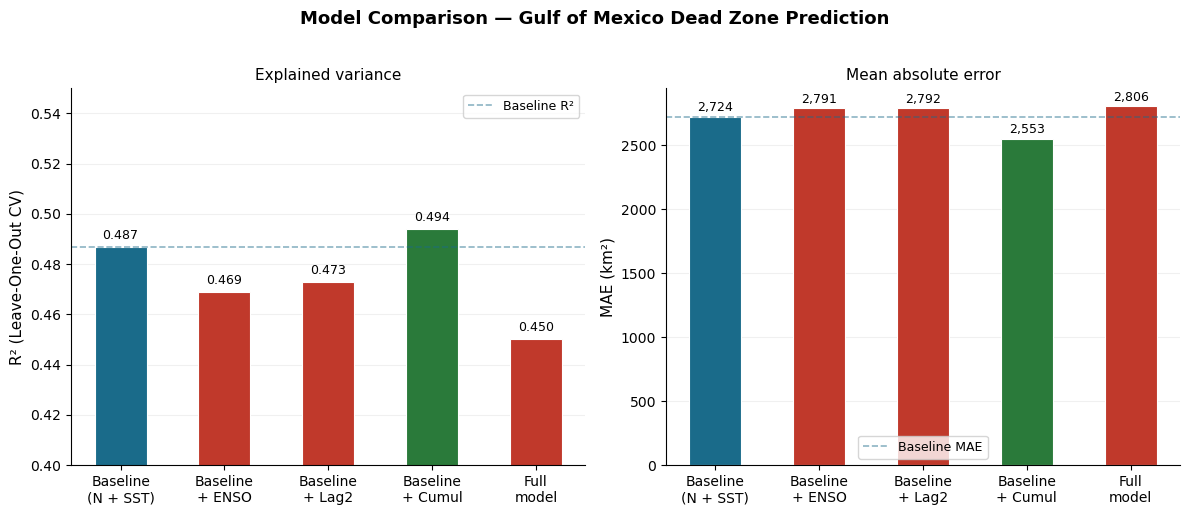

Saved model_comparison.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Baseline\n(N + SST)', 'Baseline\n+ ENSO', 'Baseline\n+ Lag2', 'Baseline\n+ Cumul', 'Full\nmodel']
r2_vals = [0.487, 0.469, 0.473, 0.494, 0.450]
mae_vals = [2724, 2791, 2792, 2553, 2806]
colors = ['#1a6b8a' if r >= 0.487 else '#c0392b' for r in r2_vals]
colors[3] = '#2a7a3a'  # best model green

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Comparison — Gulf of Mexico Dead Zone Prediction', 
             fontsize=13, fontweight='bold', y=1.02)

# R² comparison
bars1 = axes[0].bar(models, r2_vals, color=colors, width=0.5, edgecolor='white', linewidth=0.8)
axes[0].axhline(0.487, color='#1a6b8a', linestyle='--', linewidth=1.2, alpha=0.5, label='Baseline R²')
axes[0].set_ylim(0.40, 0.55)
axes[0].set_ylabel('R² (Leave-One-Out CV)', fontsize=11)
axes[0].set_title('Explained variance', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].yaxis.grid(True, color='#f0f0f0', linewidth=0.8)
axes[0].set_axisbelow(True)
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# MAE comparison
bars2 = axes[1].bar(models, mae_vals, color=colors, width=0.5, edgecolor='white', linewidth=0.8)
axes[1].axhline(2724, color='#1a6b8a', linestyle='--', linewidth=1.2, alpha=0.5, label='Baseline MAE')
axes[1].set_ylabel('MAE (km²)', fontsize=11)
axes[1].set_title('Mean absolute error', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].yaxis.grid(True, color='#f0f0f0', linewidth=0.8)
axes[1].set_axisbelow(True)
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_comparison.png")